In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df = pd.read_csv("data/2025_parkinsons.csv")

# Drop non-numeric / identifier columns
features = df.drop(columns=["name", "status"]).columns.tolist()

In [ ]:
# Shapiro-Wilk normality test
alpha = 0.05
results = []

for col in features:
    data = df[col].dropna()
    stat, p = stats.shapiro(data)
    skewness = stats.skew(data)
    results.append({
        "feature": col,
        "shapiro_stat": round(stat, 4),
        "p_value": round(p, 4),
        "p_value_raw": p,          # unrounded, for plotting
        "normal": p >= alpha,
        "skewness": round(skewness, 4),
    })

results_df = pd.DataFrame(results).sort_values("p_value")

print("Shapiro-Wilk Normality Test Results:")
print(f"Alpha = {alpha}, H0: data is normally distributed\n")
print(results_df.to_string(index=False))

# Features that are NOT normally distributed AND positively skewed -> candidates for log transform
log_candidates = results_df[
    (~results_df["normal"]) & (results_df["skewness"] > 0)
]["feature"].tolist()

print("\nRecommended for log transformation")
print("(non-normal, positively skewed)")
for f in log_candidates:
    row = results_df[results_df["feature"] == f].iloc[0]
    print(f"  {f:30s}  skewness={row['skewness']:+.4f}  p={row['p_value']:.4f}")


Shapiro-Wilk Normality Test Results:
Alpha = 0.05  |  H0: data is normally distributed

         feature  shapiro_stat  p_value  p_value_raw  normal  skewness
     MDVP:Fo(Hz)        0.9371   0.0000 1.733784e-07   False    0.5872
             NHR        0.5234   0.0000 9.394845e-23   False    4.1882
     Shimmer:DDA        0.8449   0.0000 4.141201e-13   False    1.5736
        MDVP:APQ        0.7626   0.0000 1.869091e-16   False    2.5979
    Shimmer:APQ5        0.8130   0.0000 1.814959e-14   False    1.7766
MDVP:Shimmer(dB)        0.8038   0.0000 6.988661e-15   False    1.9777
    MDVP:Shimmer        0.8367   0.0000 1.746106e-13   False    1.6506
    Shimmer:APQ3        0.8467   0.0000 4.604236e-13   False    1.5684
        MDVP:PPQ        0.6774   0.0000 4.841103e-19   False    3.0632
        MDVP:RAP        0.6485   0.0000 8.171202e-20   False    3.3289
MDVP:Jitter(Abs)        0.7665   0.0000 2.566381e-16   False    2.6287
  MDVP:Jitter(%)        0.6835   0.0000 6.428095e-19   False

In [ ]:

# Apply log1p transform to candidates and compare
print("\nSkewness before vs after log1p transform")
for f in log_candidates:
    data = df[f].dropna()
    if (data > 0).all():
        transformed = np.log(data)
    else:
        transformed = np.log1p(data - data.min())  # shift if non-positive values exist
    _, p_after = stats.shapiro(transformed)
    skew_after = round(stats.skew(transformed), 4)
    skew_before = round(stats.skew(data), 4)
    improved = "✓" if abs(skew_after) < abs(skew_before) else "✗"
    print(f"  {improved} {f:30s}  skew {skew_before:+.4f} → {skew_after:+.4f}  p_after={p_after:.4f}")



=== Skewness before vs after log1p transform ===
  ✓ MDVP:Fo(Hz)                     skew +0.5872 → +0.2125  p_after=0.0000
  ✓ NHR                             skew +4.1882 → +0.3164  p_after=0.0871
  ✓ Shimmer:DDA                     skew +1.5736 → +0.3251  p_after=0.0036
  ✓ MDVP:APQ                        skew +2.5979 → +0.5879  p_after=0.0002
  ✓ Shimmer:APQ5                    skew +1.7766 → +0.5082  p_after=0.0001
  ✓ MDVP:Shimmer(dB)                skew +1.9777 → +0.4899  p_after=0.0007
  ✓ MDVP:Shimmer                    skew +1.6506 → +0.4327  p_after=0.0005
  ✓ Shimmer:APQ3                    skew +1.5684 → +0.3151  p_after=0.0042
  ✓ MDVP:PPQ                        skew +3.0632 → +0.7630  p_after=0.0001
  ✓ MDVP:RAP                        skew +3.3289 → +0.6940  p_after=0.0002
  ✓ MDVP:Jitter(Abs)                skew +2.6287 → -0.0743  p_after=0.0001
  ✓ MDVP:Jitter(%)                  skew +3.0612 → +0.6760  p_after=0.0003
  ✓ MDVP:Flo(Hz)                    skew +1.2080 →

In [4]:
# visualization

def log_transform(series):
    if (series > 0).all():
        return np.log(series)
    return np.log1p(series - series.min())

# Build a transform comparison table for all log candidates
transform_rows = []
for f in log_candidates:
    data = df[f].dropna()
    transformed = log_transform(data)
    _, p_after = stats.shapiro(transformed)
    transform_rows.append({
        "feature": f,
        "skew_before": stats.skew(data),
        "skew_after": stats.skew(transformed),
        "p_after": p_after,
        "improved": abs(stats.skew(transformed)) < abs(stats.skew(data)),
    })
transform_df = pd.DataFrame(transform_rows)


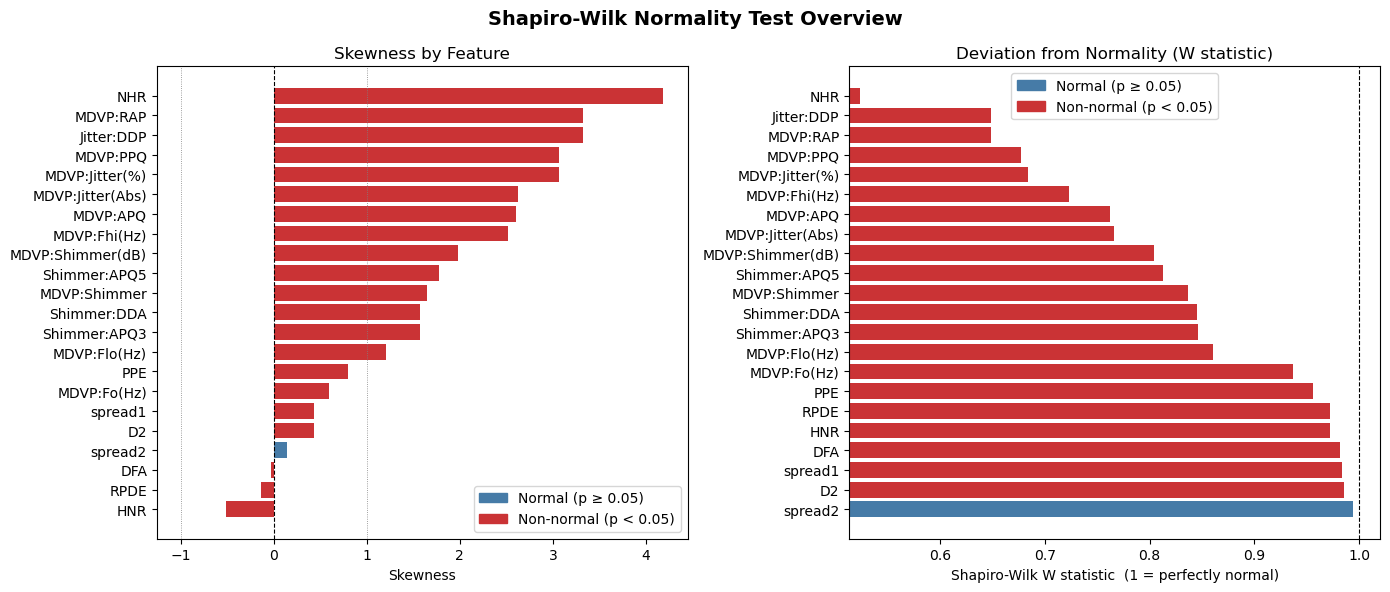

In [ ]:
# Shapiro-Wilk plot (skewness + normality per feature) 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Shapiro-Wilk Normality Test", fontsize=14, fontweight="bold")

# Left: skewness of all features, coloured by normality
plot_df = results_df.sort_values("skewness")
colors = ["#467ba7" if n else "#ca3335" for n in plot_df["normal"]]
axes[0].barh(plot_df["feature"], plot_df["skewness"], color=colors)
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].axvline(1, color="grey", linewidth=0.6, linestyle=":")
axes[0].axvline(-1, color="grey", linewidth=0.6, linestyle=":")
axes[0].set_xlabel("Skewness")
axes[0].set_title("Skewness by Feature")
axes[0].legend(handles=[
    Patch(color="#467ba7", label="Normal (p ≥ 0.05)"),
    Patch(color="#ca3335", label="Non-normal (p < 0.05)"),
])

# Right: Shapiro-Wilk W statistic (more informative than p-value when p approx 0 for most features)
plot_df2 = results_df.sort_values("shapiro_stat", ascending=False)
bar_colors = ["#ca3335" if not n else "#467ba7" for n in plot_df2["normal"]]
axes[1].barh(plot_df2["feature"], plot_df2["shapiro_stat"], color=bar_colors)
axes[1].axvline(1.0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlim(left=plot_df2["shapiro_stat"].min() - 0.01, right=1.02)
axes[1].set_xlabel("Shapiro-Wilk W statistic  (1 = perfectly normal)")
axes[1].set_title("Deviation from Normality (W statistic)")
axes[1].legend(handles=[
    Patch(color="#467ba7", label="Normal (p ≥ 0.05)"),
    Patch(color="#ca3335", label="Non-normal (p < 0.05)"),
])

plt.tight_layout()
plt.savefig("plots/shapiro_overview.png", dpi=150, bbox_inches="tight")
plt.show()

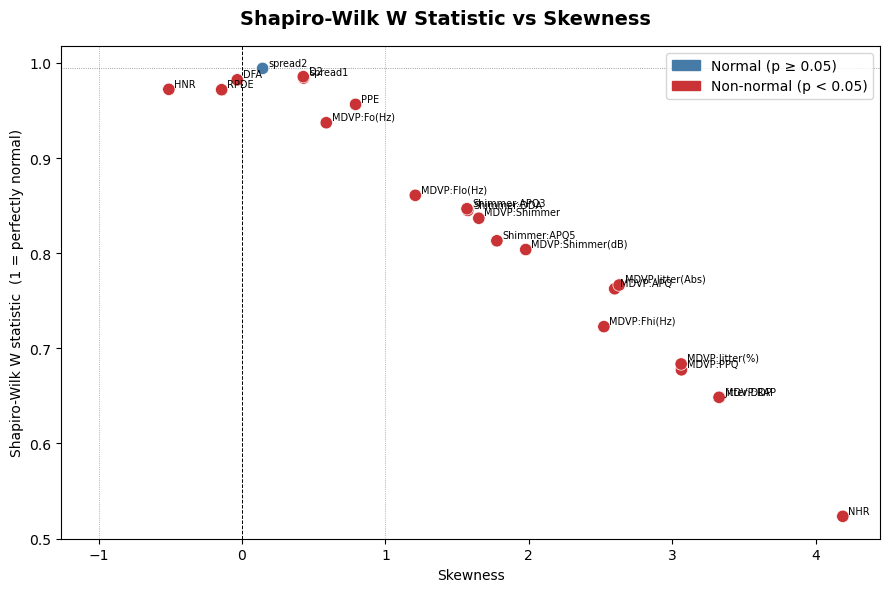

In [6]:
# Scatterplot of Shapiro W statistic vs skewness
fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle("Shapiro-Wilk W Statistic vs Skewness", fontsize=14, fontweight="bold")

scatter_colors = ["#467ba7" if n else "#ca3335" for n in results_df["normal"]]
ax.scatter(results_df["skewness"], results_df["shapiro_stat"],
           c=scatter_colors, s=80, edgecolors="white", linewidths=0.5, zorder=3)

ax.axhline(results_df[results_df["normal"]]["shapiro_stat"].min() if results_df["normal"].any() else 0.95,
           color="grey", linewidth=0.6, linestyle=":")
ax.axvline(0, color="black", linewidth=0.7, linestyle="--")
ax.axvline(1,  color="grey", linewidth=0.5, linestyle=":")
ax.axvline(-1, color="grey", linewidth=0.5, linestyle=":")

for _, row in results_df.iterrows():
    ax.annotate(row["feature"], (row["skewness"], row["shapiro_stat"]),
                fontsize=7, xytext=(4, 2), textcoords="offset points")

ax.set_xlabel("Skewness")
ax.set_ylabel("Shapiro-Wilk W statistic  (1 = perfectly normal)")
ax.legend(handles=[
    Patch(color="#467ba7", label="Normal (p ≥ 0.05)"),
    Patch(color="#ca3335", label="Non-normal (p < 0.05)"),
])

plt.tight_layout()
plt.savefig("plots/shapiro_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


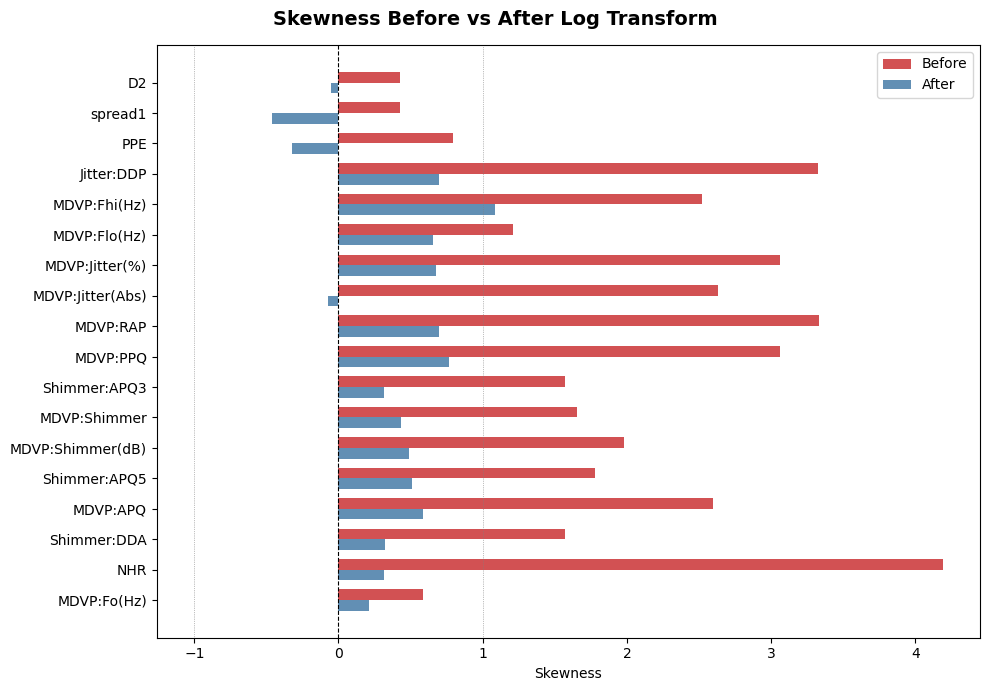

In [7]:
# Skewness before vs after log transform 
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle("Skewness Before vs After Log Transform", fontsize=14, fontweight="bold")

y = np.arange(len(transform_df))
bar_h = 0.35
ax.barh(y + bar_h/2, transform_df["skew_before"], bar_h, label="Before", color="#ca3335", alpha=0.85)
ax.barh(y - bar_h/2, transform_df["skew_after"],  bar_h, label="After",  color="#467ba7", alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.axvline(1,  color="grey", linewidth=0.5, linestyle=":")
ax.axvline(-1, color="grey", linewidth=0.5, linestyle=":")
ax.set_yticks(y)
ax.set_yticklabels(transform_df["feature"])
ax.set_xlabel("Skewness")
ax.legend()

plt.tight_layout()
plt.savefig("plots/log_transform_skewness.png", dpi=150, bbox_inches="tight")
plt.show()


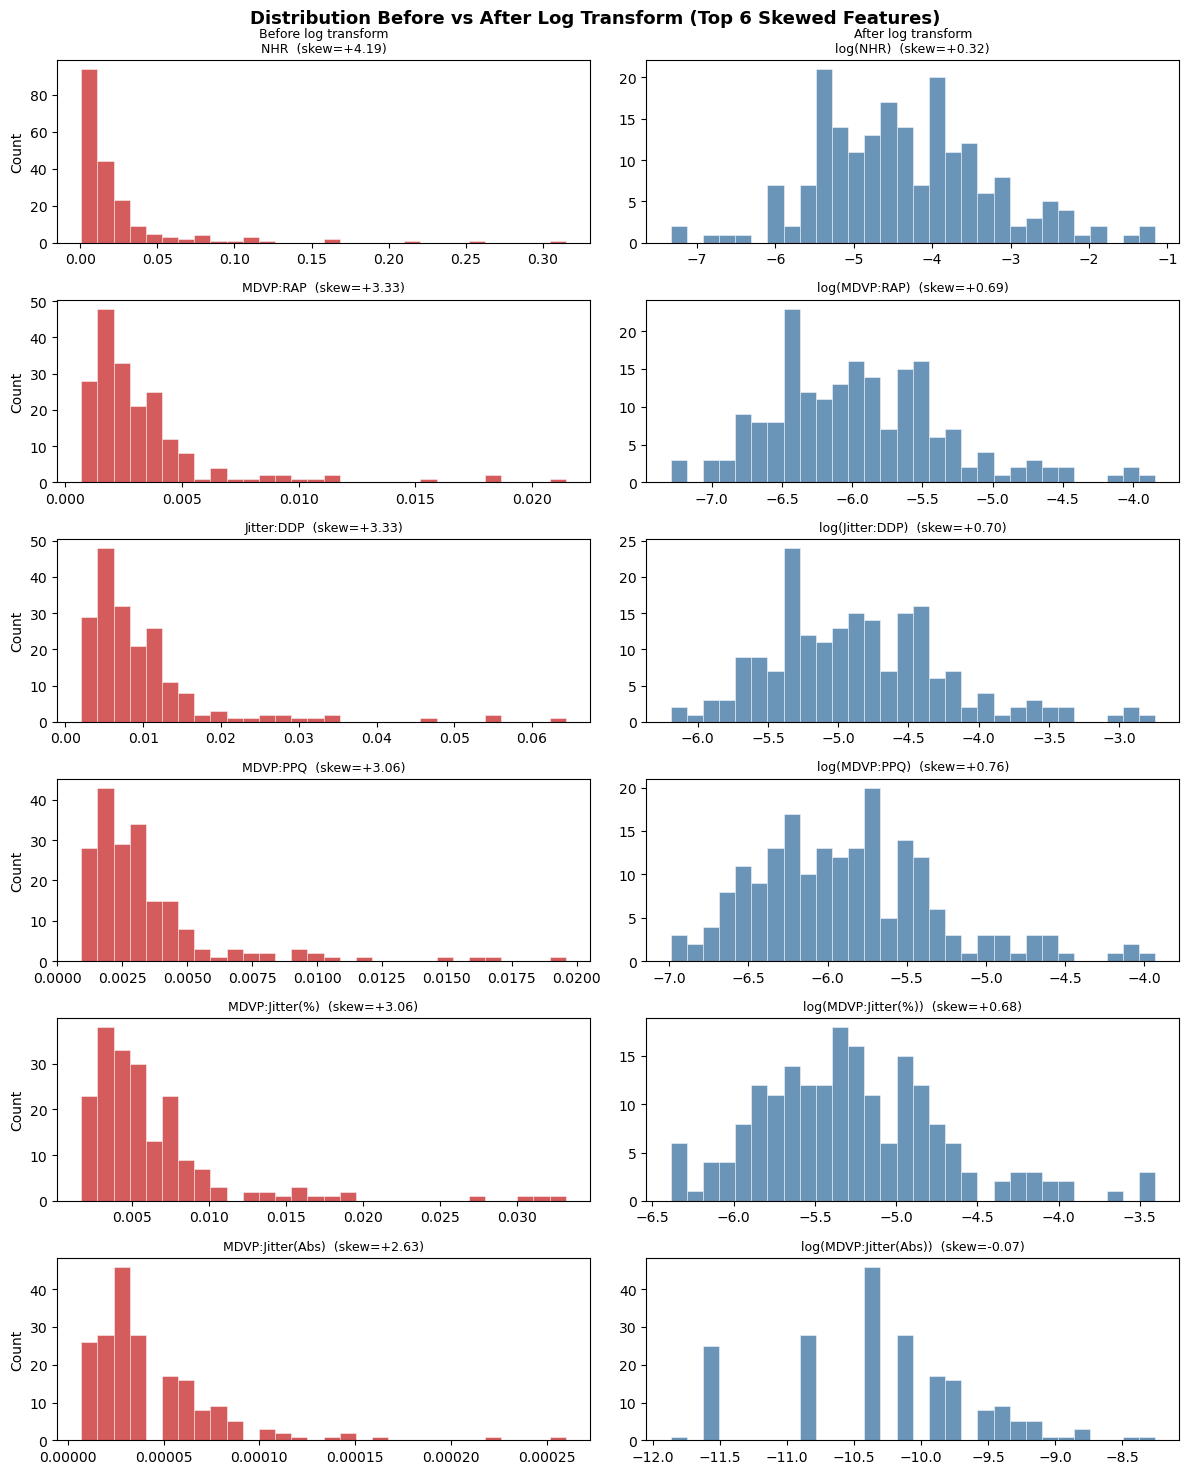

In [8]:
# Histograms before/after for top-skewed features
top_features = transform_df.sort_values("skew_before", ascending=False).head(6)["feature"].tolist()

fig, axes = plt.subplots(len(top_features), 2, figsize=(12, len(top_features) * 2.5))
fig.suptitle("Distribution Before vs After Log Transform (Top 6 Skewed Features)",
             fontsize=13, fontweight="bold")

for i, f in enumerate(top_features):
    data = df[f].dropna()
    transformed = log_transform(data)
    skew_b = stats.skew(data)
    skew_a = stats.skew(transformed)

    axes[i, 0].hist(data, bins=30, color="#ca3335", alpha=0.8, edgecolor="white", linewidth=0.4)
    axes[i, 0].set_title(f"{f}  (skew={skew_b:+.2f})", fontsize=9)
    axes[i, 0].set_ylabel("Count")

    axes[i, 1].hist(transformed, bins=30, color="#467ba7", alpha=0.8, edgecolor="white", linewidth=0.4)
    axes[i, 1].set_title(f"log({f})  (skew={skew_a:+.2f})", fontsize=9)

axes[0, 0].set_title("Before log transform\n" + axes[0, 0].get_title(), fontsize=9)
axes[0, 1].set_title("After log transform\n" + axes[0, 1].get_title(), fontsize=9)

plt.tight_layout()
plt.savefig("plots/histograms_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

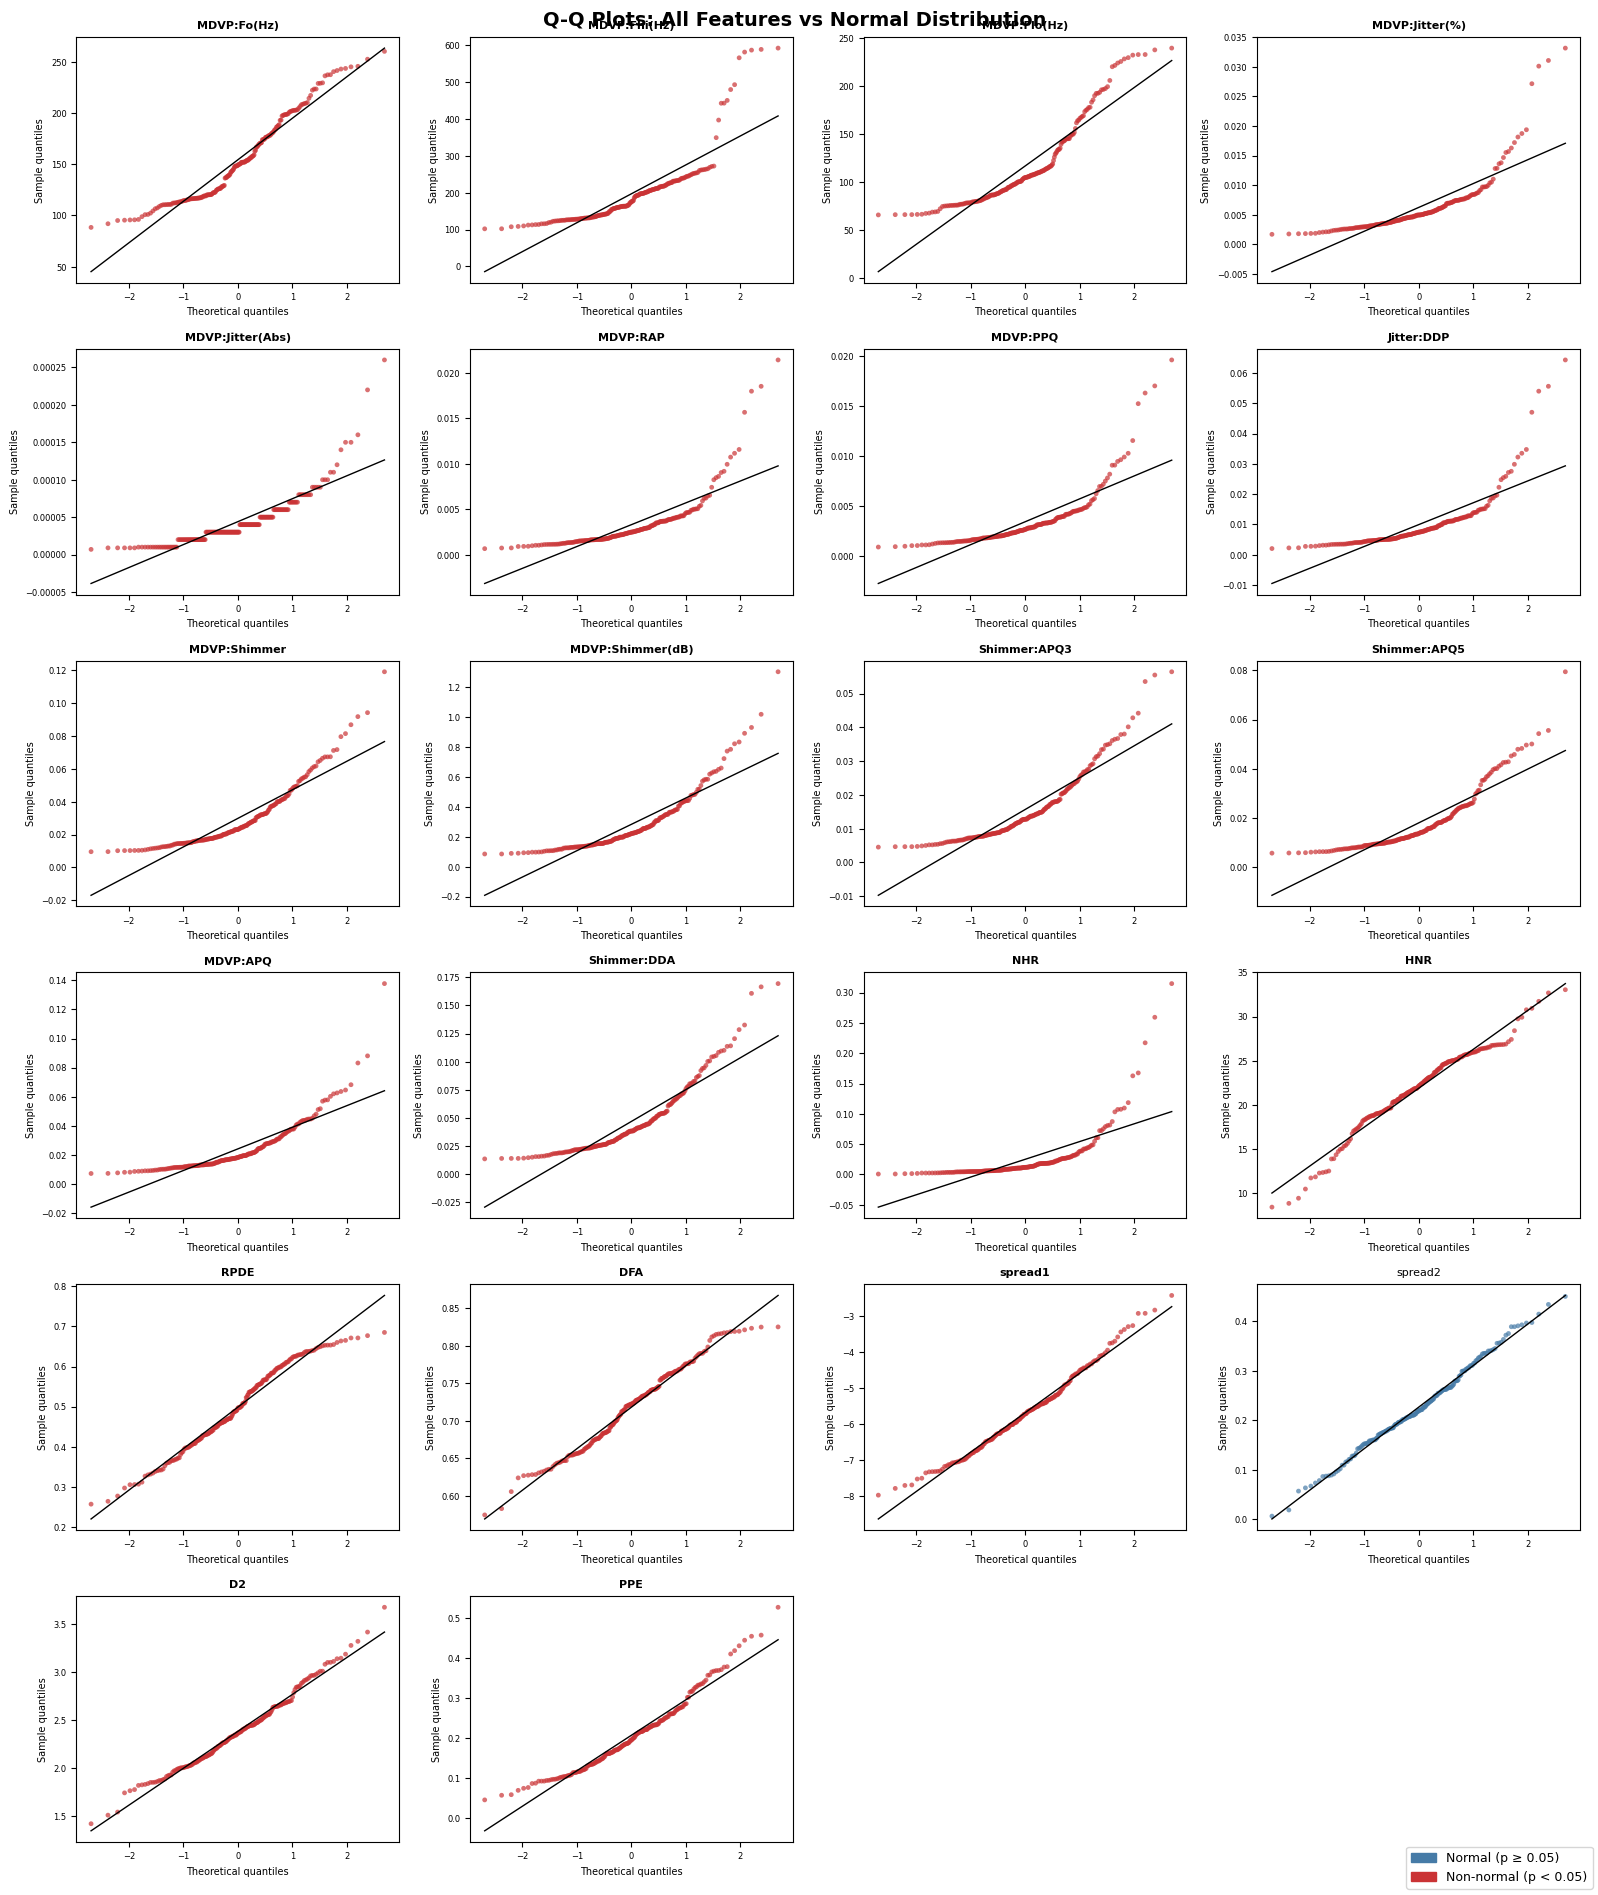

In [9]:
# Q-Q plots
n_cols = 4
n_rows = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.2))
fig.suptitle("Q-Q Plots: All Features vs Normal Distribution", fontsize=14, fontweight="bold")
axes_flat = axes.flatten()

for i, f in enumerate(features):
    ax = axes_flat[i]
    data = df[f].dropna()
    is_normal = results_df.loc[results_df["feature"] == f, "normal"].values[0]
    color = "#467ba7" if is_normal else "#ca3335"

    (osm, osr), (slope, intercept, _) = stats.probplot(data, dist="norm")
    ax.scatter(osm, osr, color=color, s=12, alpha=0.7, edgecolors="none")
    ax.plot([osm[0], osm[-1]],
            [slope * osm[0] + intercept, slope * osm[-1] + intercept],
            color="black", linewidth=1)
    ax.set_title(f, fontsize=8, fontweight="bold" if not is_normal else "normal")
    ax.set_xlabel("Theoretical quantiles", fontsize=7)
    ax.set_ylabel("Sample quantiles", fontsize=7)
    ax.tick_params(labelsize=6)

# Hide unused subplots
for j in range(len(features), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.legend(handles=[
    Patch(color="#467ba7", label="Normal (p ≥ 0.05)"),
    Patch(color="#ca3335", label="Non-normal (p < 0.05)"),
], loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("plots/qq_plots.png", dpi=150, bbox_inches="tight")
plt.show()


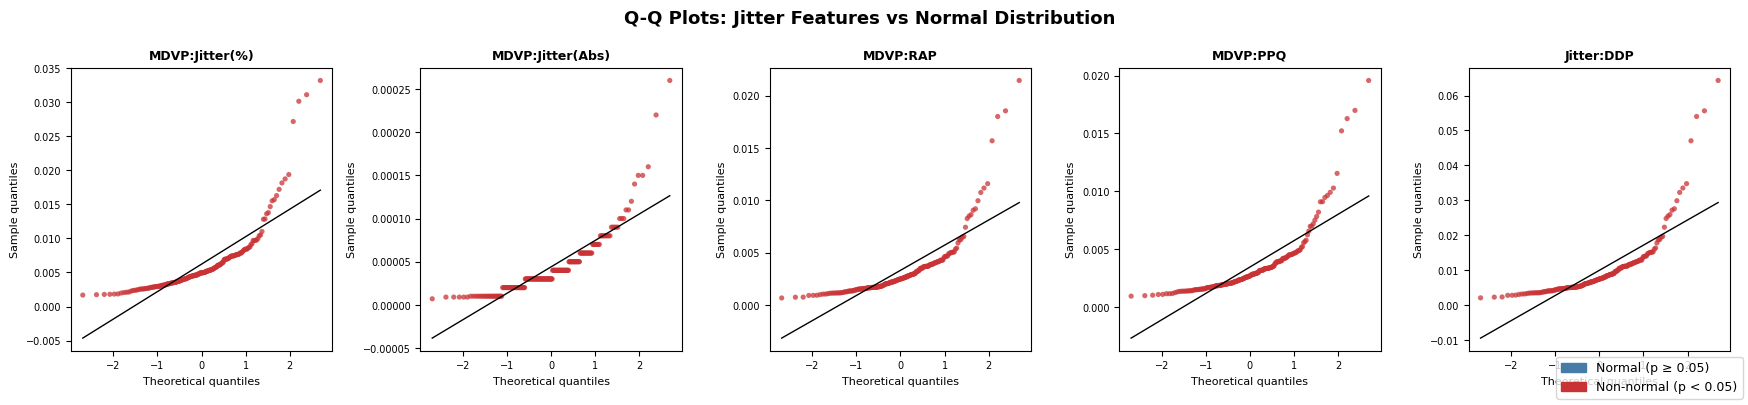

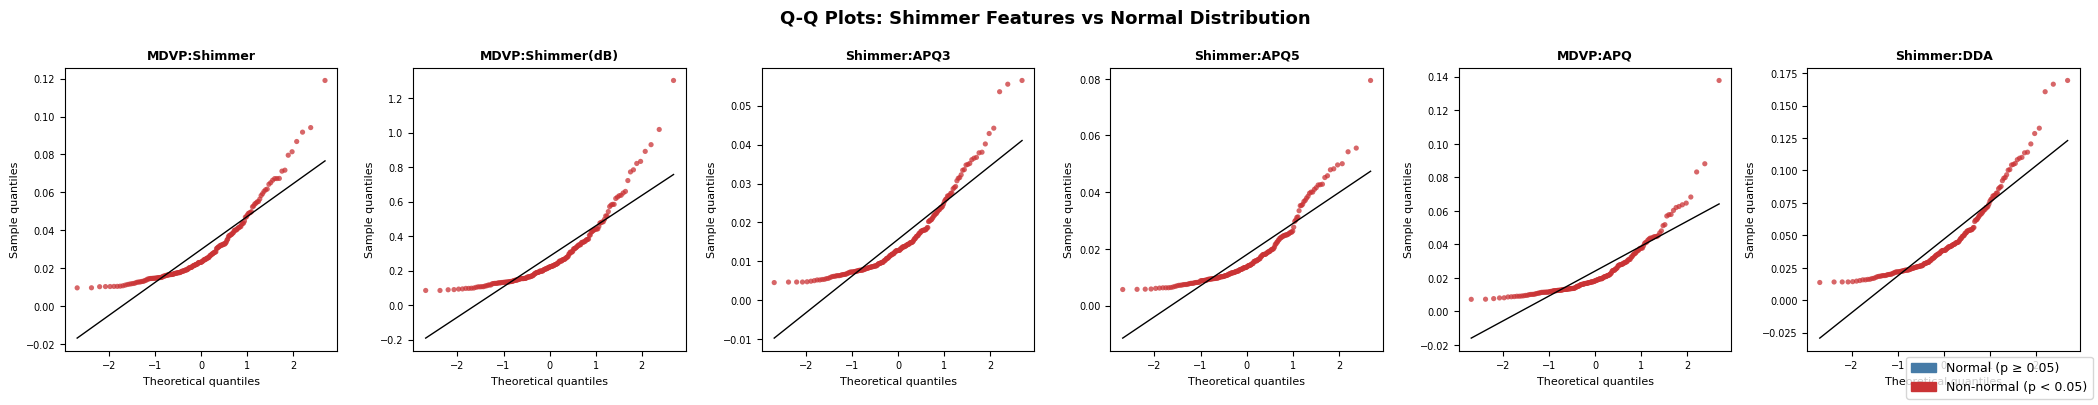


Plots saved to plots/


In [10]:
# Q-Q plots for just Jitter and Shimmer
jitter_features  = [f for f in features if "jitter" in f.lower() or f in ("MDVP:RAP", "MDVP:PPQ")]
shimmer_features = [f for f in features if "shimmer" in f.lower() or "apq" in f.lower()]

def qq_group_plot(group_features, title, filename):
    n = len(group_features)
    fig, axes = plt.subplots(1, n, figsize=(n * 3.5, 4))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    if n == 1:
        axes = [axes]

    for ax, f in zip(axes, group_features):
        data = df[f].dropna()
        is_normal = results_df.loc[results_df["feature"] == f, "normal"].values[0]
        color = "#467ba7" if is_normal else "#ca3335"

        (osm, osr), (slope, intercept, _) = stats.probplot(data, dist="norm")
        ax.scatter(osm, osr, color=color, s=14, alpha=0.75, edgecolors="none")
        ax.plot([osm[0], osm[-1]],
                [slope * osm[0] + intercept, slope * osm[-1] + intercept],
                color="black", linewidth=1)
        ax.set_title(f, fontsize=9, fontweight="bold")
        ax.set_xlabel("Theoretical quantiles", fontsize=8)
        ax.set_ylabel("Sample quantiles", fontsize=8)
        ax.tick_params(labelsize=7)

    fig.legend(handles=[
        Patch(color="#467ba7", label="Normal (p ≥ 0.05)"),
        Patch(color="#ca3335", label="Non-normal (p < 0.05)"),
    ], loc="lower right", fontsize=9)

    plt.tight_layout()
    plt.savefig(f"plots/{filename}", dpi=150, bbox_inches="tight")
    plt.show()

qq_group_plot(jitter_features,  "Q-Q Plots: Jitter Features vs Normal Distribution",  "qq_jitter.png")
qq_group_plot(shimmer_features, "Q-Q Plots: Shimmer Features vs Normal Distribution", "qq_shimmer.png")

print("\nPlots saved to plots/")